In [1]:
import sys
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.append(os.path.abspath("/home/anushkasingh/Desktop/Thesis/Code/Baseline Correction"))
from load_data import read_data, create_combined_dataset
from baseline_correct import baseline_roy

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


from scipy.stats import f_oneway
import seaborn as sns


In [2]:
path = ["../ALLDataGross/allKgData",
    "../ALLDataGross/BlindData",
    "../ALLDataGross/healthyCohort"
]
normVP = [[504, 425, 451, 454, 450, 474, 451, 471, 540, 467,
    550, 468, 481, 450, 515, 441, 452, 462, 453, 450, 452, 
    490, 504, 520, 525, 498, 542, 527, 550],
        [505, 503, 478, 453, 460, 494, 410, 413, 479, 489, 
    473, 464, 445, 499, 406, 455, 481, 388, 428, 466, 463, 
    520, 461],
    [420, 420, 428, 448, 417, 430, 420, 449, 483, 499, 
    438, 465, 438, 428, 503, 505, 504, 454, 515, 441, 
    404, 363]]
infoP = [["H", "PC", "PC", "H", "PC", "BC", "PC", "PC", "BC", "BC", 
    "PC", "PC", "PC", "PC", "H", "H","PC", "PC", "KC", "PC", "KC", 
    "PC", "BC", "BC", "PC", "KC", "PC", "PC", "PC"],
        ["H", "H" ,"H" ,"H", "KG", "KG", "KG", "KG", "KG", "KG", "KG", "KG", "KG" ,
     "KG", "KG", "KG", "KG", "KG" ,"KG", "KG" ,"KG", "KG", "KG"],
          ["F", "M", "M", "F", "F", "F", "F", "M", "M", "M", 
    "M", "F", "M", "M", "F", "M" ,"M", "M", "M", "M", 
    "M", "M" ]
]
df = create_combined_dataset(path,normVP,infoP)

df['intensity_baseline_corrected'] = None
for idx, row in df.iterrows():
    df.at[idx, "intensity_baseline_corrected"] = baseline_roy(x=row["wavenumber"], y=row["intensity"], norm_factor_i=row['normVP'])
    print(f"{idx} done!")
print("baseline corrected!")

Folder exists: True
Folder contents: [PosixPath('../ALLDataGross/allKgData/20190801-02-023.dpt'), PosixPath('../ALLDataGross/allKgData/dataLoadKGall.m'), PosixPath('../ALLDataGross/allKgData/20190801-01-022.dpt'), PosixPath('../ALLDataGross/allKgData/20190606-04-012.dpt'), PosixPath('../ALLDataGross/allKgData/20190801-03-024.dpt'), PosixPath('../ALLDataGross/allKgData/20190405-05-004.dpt'), PosixPath('../ALLDataGross/allKgData/20190405-12-010.dpt'), PosixPath('../ALLDataGross/allKgData/20190606-10-018.dpt'), PosixPath('../ALLDataGross/allKgData/20190606-05-013.dpt'), PosixPath('../ALLDataGross/allKgData/20190801-07-028.dpt'), PosixPath('../ALLDataGross/allKgData/20190405-04-003.dpt'), PosixPath('../ALLDataGross/allKgData/20190606-09-017.dpt'), PosixPath('../ALLDataGross/allKgData/20190405-03-002.dpt'), PosixPath('../ALLDataGross/allKgData/20190606-06-014.dpt'), PosixPath('../ALLDataGross/allKgData/20190405-02-001.dpt'), PosixPath('../ALLDataGross/allKgData/20190606-13-021.dpt'), PosixP

In [3]:
print(df["category"].value_counts())
print(df["infoP"].value_counts())
df = df[df["category"]!= "blinddata"]
print(df["category"].unique())

category
allkgdata      29
blinddata      23
healthydata    22
Name: count, dtype: int64
infoP
KG    19
PC    17
M     15
H      8
F      7
BC     5
KC     3
Name: count, dtype: int64
['allkgdata' 'healthydata']


In [4]:
df["class"] = df["infoP"].apply(lambda x: "H" if x in ["M", "F", "H"] else x)

In [5]:
df["class"].value_counts()

class
H     26
PC    17
BC     5
KC     3
Name: count, dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 51 entries, 0 to 73
Data columns (total 10 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   patient_id                    51 non-null     object
 1   original_filename             51 non-null     object
 2   category                      51 non-null     object
 3   normVP                        51 non-null     int64 
 4   infoP                         51 non-null     object
 5   wavenumber                    51 non-null     object
 6   intensity                     51 non-null     object
 7   spectrum_length               51 non-null     int64 
 8   intensity_baseline_corrected  51 non-null     object
 9   class                         51 non-null     object
dtypes: int64(2), object(8)
memory usage: 4.4+ KB


### Binary Claaification

In [7]:
df_bin = df[df["class"].isin(["PC", "H"])].copy() #remove KC BC
y = (df_bin["class"] == "PC").astype(int).values

In [8]:
X = np.vstack(
    df_bin["intensity_baseline_corrected"]
        .apply(np.asarray)
        .values
)
# X shape: (n_samples, n_wavenumbers)
X.shape

(43, 14517)

In [9]:
# t = np.asarray(df_bin.iloc[0]["wavenumber"])
# Each row = one function in X
# Columns correspond to same grid points

X_mean = X.mean(axis=0)
X_centered = X - X_mean

In [10]:
from sklearn.decomposition import PCA

pca = PCA(svd_solver="full")
scores = pca.fit_transform(X_centered)
cumvar = np.cumsum(pca.explained_variance_ratio_)
K = np.searchsorted(cumvar, 0.95) + 1

scores_K = scores[:, :K]
# scores_K

In [11]:
from sklearn.svm import SVC

clf = SVC(kernel="rbf", C=1.0, gamma="scale")
clf.fit(scores_K, y)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [12]:
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import balanced_accuracy_score

loo = LeaveOneOut()
y_true, y_pred, decisions = [], [], []

for train_idx, test_idx in loo.split(X):
    X_tr, X_te = X[train_idx], X[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]

    # Center on training data only
    mean_tr = X_tr.mean(axis=0)
    X_tr_c = X_tr - mean_tr
    X_te_c = X_te - mean_tr

    pca = PCA()
    scores_tr = pca.fit_transform(X_tr_c)

    cumvar = np.cumsum(pca.explained_variance_ratio_)
    K = np.searchsorted(cumvar, 0.95) + 1

    scores_tr = scores_tr[:, :K]
    scores_te = pca.transform(X_te_c)[:, :K]

    

    clf = SVC(kernel="rbf", C=100)#, class_weight="balanced")
    clf.fit(scores_tr, y_tr)

    decision = clf.decision_function(scores_te)[0]
    pred = (decision> 0).astype(int)

    decisions.append(decision)
    y_pred.append(pred)
    y_true.append(y_te[0])

# bal_acc = balanced_accuracy_score(y_true, y_pred)
results_whole = {
    "y_true": np.array(y_true),
    "y_pred": np.array(y_pred),
    "decisions": np.array(decisions),
    "balanced_accuracy": balanced_accuracy_score(y_true, y_pred)
}


In [13]:
results_whole

{'y_true': array([0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
 'y_pred': array([0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
 'decisions': array([-1.03012673,  6.22653483,  1.0743361 , -0.46896814, -1.82840828,
         1.89290828,  0.7318998 ,  2.39291061,  0.2603138 , -1.34293488,
        -1.62989232, -0.21697223, -0.93706467,  0.89103275,  1.08174323,
         6.34540939,  0.94725744,  1.77629027,  0.57620189,  1.52527845,
        -0.3885839 , -1.42989888, -1.34959736, -1.35016345, -1.47079807,
        -1.32989257, -1.44032021, -1.36107262, -1.30725512, -1.30110701,
        -1.27292681,  0.55534445, -0.19382744, -0.62053473, -1.50589034,
        -0.60793464, -1.15416814, -1.03012673, -0.46896814, -0.21697223,
        -0.93706467, -1.44138542, -0.60488633]),
 'balanced_accuracy': 0.8631221719457014

In [14]:
import matplotlib.pyplot as plt
import numpy as np

def plot_decision_values(decisions, y_true, title):
    y_num = np.array([1 if y == "PC" else -1 for y in y_true])

    assert len(decisions) == len(y_true)
    
    plt.figure(figsize=(7,4))
    for cls, label in [(1, "PC"), (0, "H")]:
        idx = y_num == cls
        plt.scatter(
            np.where(idx)[0],
            decisions[idx],
            label=label,
            alpha=0.8
        )

    plt.axhline(0, color="black", linestyle="--")
    plt.xlabel("Sample index")
    plt.ylabel("Decision value f(x)")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


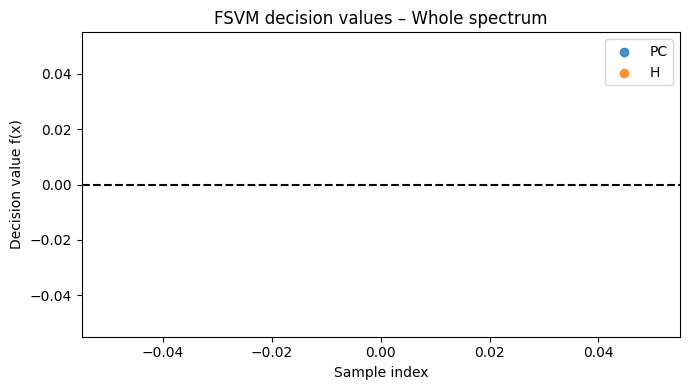

In [15]:
plot_decision_values(
    decisions=results_whole["y_pred"],
    y_true=results_whole["y_true"],
    title="FSVM decision values – Whole spectrum"
)


In [16]:
def plot_margin_histogram(decisions, y_true, title):
    y_num = np.array([1 if y == "PC" else -1 for y in y_true])

    plt.figure(figsize=(6,4))
    plt.hist(decisions[y_num == 1], bins=10, alpha=0.7, label="PC")
    plt.hist(decisions[y_num == -1], bins=10, alpha=0.7, label="H")
    plt.axvline(0, color="black", linestyle="--")
    plt.xlabel("Decision value")
    plt.ylabel("Count")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


In [17]:
decisions=results_whole["decisions"]
y_true=results_whole["y_true"]
decisions, y_true


(array([-1.03012673,  6.22653483,  1.0743361 , -0.46896814, -1.82840828,
         1.89290828,  0.7318998 ,  2.39291061,  0.2603138 , -1.34293488,
        -1.62989232, -0.21697223, -0.93706467,  0.89103275,  1.08174323,
         6.34540939,  0.94725744,  1.77629027,  0.57620189,  1.52527845,
        -0.3885839 , -1.42989888, -1.34959736, -1.35016345, -1.47079807,
        -1.32989257, -1.44032021, -1.36107262, -1.30725512, -1.30110701,
        -1.27292681,  0.55534445, -0.19382744, -0.62053473, -1.50589034,
        -0.60793464, -1.15416814, -1.03012673, -0.46896814, -0.21697223,
        -0.93706467, -1.44138542, -0.60488633]),
 array([0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]))

## Binary FSVM on Whole Spectrum - cleaner code

In [18]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import balanced_accuracy_score


In [19]:
df_bin = df[df["class"].isin(["PC", "H"])].copy()

y = (df_bin["class"] == "PC").astype(int).values

X = np.vstack(
    df_bin["intensity_baseline_corrected"]
        .apply(np.asarray)
        .values
)

# X shape: (n_samples, n_wavenumbers)
print("X shape:", X.shape)


X shape: (43, 14517)


In [20]:
X_mean = X.mean(axis=0)
X_centered = X - X_mean

pca = PCA(svd_solver="full")
scores = pca.fit_transform(X_centered)

cumvar = np.cumsum(pca.explained_variance_ratio_)
K = np.searchsorted(cumvar, 0.95) + 1

scores_K = scores[:, :K]
print("Number of PCs retained:", K)


Number of PCs retained: 6


In [21]:
clf = SVC(kernel="rbf", C=1.0, gamma="scale")
clf.fit(scores_K, y)


,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [22]:
loo = LeaveOneOut()

y_true = []
y_pred = []
decisions = []

for train_idx, test_idx in loo.split(X):

    X_tr, X_te = X[train_idx], X[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]

    # Center using training mean only
    mean_tr = X_tr.mean(axis=0)
    X_tr_c = X_tr - mean_tr
    X_te_c = X_te - mean_tr

    # PCA on training data only
    pca = PCA()
    scores_tr = pca.fit_transform(X_tr_c)

    cumvar = np.cumsum(pca.explained_variance_ratio_)
    K = np.searchsorted(cumvar, 0.95) + 1

    scores_tr = scores_tr[:, :K]
    scores_te = pca.transform(X_te_c)[:, :K]

    # SVM
    clf = SVC(kernel="rbf", C=100) 
    clf.fit(scores_tr, y_tr)

    decision = clf.decision_function(scores_te)[0]
    pred = (decision > 0).astype(int)

    decisions.append(decision)
    y_pred.append(pred)
    y_true.append(y_te[0])


In [23]:
results_whole = {
    "y_true": np.array(y_true),
    "y_pred": np.array(y_pred),
    "decisions": np.array(decisions),
    "balanced_accuracy": balanced_accuracy_score(y_true, y_pred)
}

results_whole


{'y_true': array([0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
 'y_pred': array([0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
 'decisions': array([-1.03012673,  6.22653483,  1.0743361 , -0.46896814, -1.82840828,
         1.89290828,  0.7318998 ,  2.39291061,  0.2603138 , -1.34293488,
        -1.62989232, -0.21697223, -0.93706467,  0.89103275,  1.08174323,
         6.34540939,  0.94725744,  1.77629027,  0.57620189,  1.52527845,
        -0.3885839 , -1.42989888, -1.34959736, -1.35016345, -1.47079807,
        -1.32989257, -1.44032021, -1.36107262, -1.30725512, -1.30110701,
        -1.27292681,  0.55534445, -0.19382744, -0.62053473, -1.50589034,
        -0.60793464, -1.15416814, -1.03012673, -0.46896814, -0.21697223,
        -0.93706467, -1.44138542, -0.60488633]),
 'balanced_accuracy': 0.8631221719457014

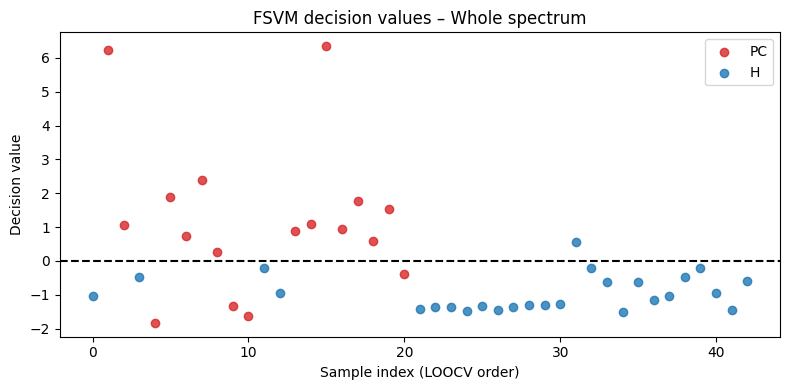

In [24]:
def plot_decision_values(decisions, y_true, title):
    decisions = np.asarray(decisions)
    y_true = np.asarray(y_true)

    plt.figure(figsize=(8, 4))

    for cls, label, color in [(1, "PC", "tab:red"), (0, "H", "tab:blue")]:
        idx = y_true == cls
        plt.scatter(
            np.where(idx)[0],
            decisions[idx],
            label=label,
            alpha=0.8,
            color=color
        )

    plt.axhline(0, color="black", linestyle="--")
    plt.xlabel("Sample index (LOOCV order)")
    plt.ylabel("Decision value")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_decision_values(
    results_whole["decisions"],
    results_whole["y_true"],
    "FSVM decision values – Whole spectrum"
)


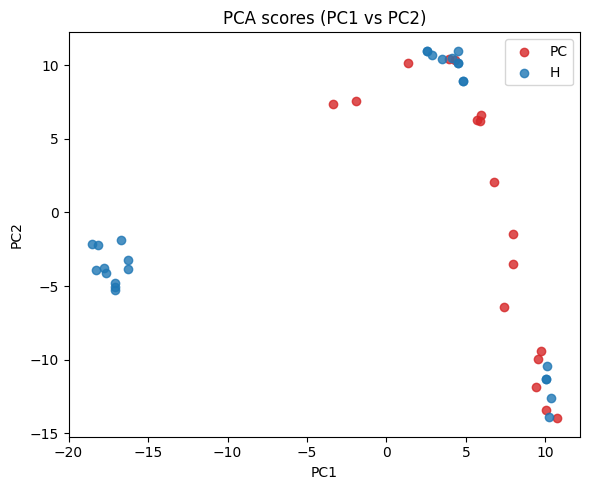

In [25]:
plt.figure(figsize=(6, 5))

for cls, label, color in [(1, "PC", "tab:red"), (0, "H", "tab:blue")]:
    idx = y == cls
    plt.scatter(
        scores[idx, 0],
        scores[idx, 1],
        label=label,
        alpha=0.8,
        color=color
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA scores (PC1 vs PC2)")
plt.legend()
plt.tight_layout()
plt.show()


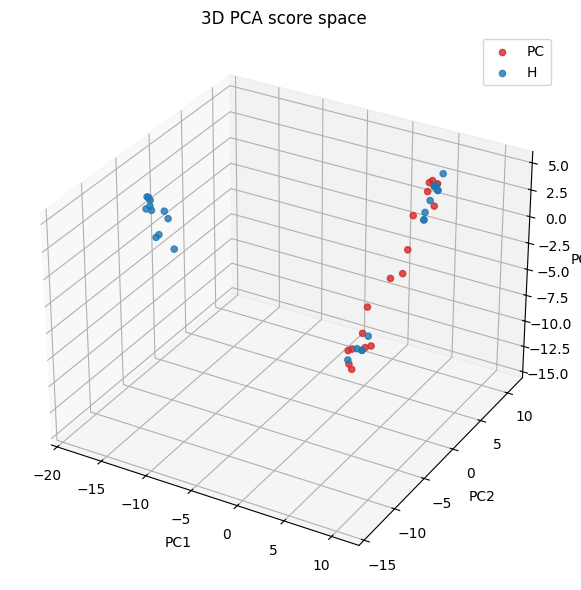

In [26]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")

for cls, label, color in [(1, "PC", "tab:red"), (0, "H", "tab:blue")]:
    idx = y == cls
    ax.scatter(
        scores[idx, 0],
        scores[idx, 1],
        scores[idx, 2],
        label=label,
        alpha=0.8,
        color=color
    )

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("3D PCA score space")
ax.legend()
plt.tight_layout()
plt.show()


/tmp/ipykernel_52784/299977664.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


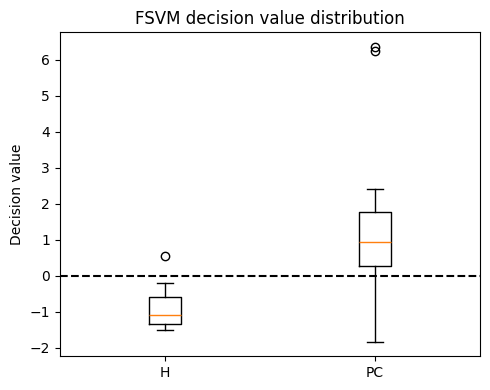

In [27]:
plt.figure(figsize=(5, 4))
plt.boxplot(
    [results_whole["decisions"][results_whole["y_true"] == 0],
     results_whole["decisions"][results_whole["y_true"] == 1]],
    labels=["H", "PC"]
)
plt.axhline(0, color="black", linestyle="--")
plt.ylabel("Decision value")
plt.title("FSVM decision value distribution")
plt.tight_layout()
plt.show()


In [28]:
X.shape[1]

14517

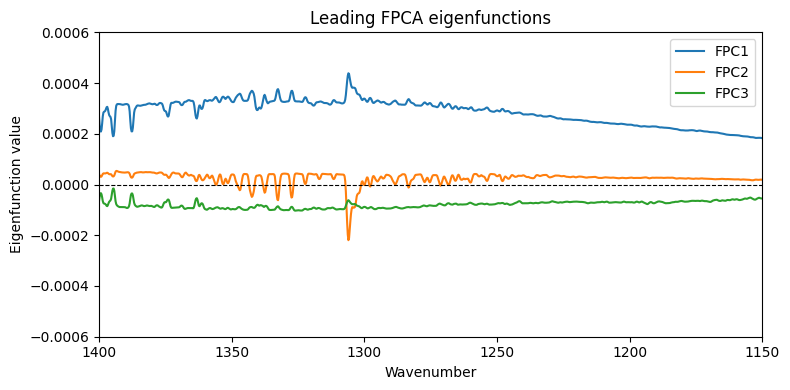

In [29]:
wavenumbers = np.linspace(500, 4000, X.shape[1])#np.arange(X.shape[1])

X_H = X[y == 0]
X_PC = X[y == 1]

mean_H = X_H.mean(axis=0)
mean_PC = X_PC.mean(axis=0)

phi = pca.components_[:3]  # first 3 eigenfunctions

plt.figure(figsize=(8, 4))
for k in range(3):
    plt.plot(wavenumbers, phi[k], label=f"FPC{k+1}")

plt.axhline(0, color="black", linestyle="--", linewidth=0.8)
plt.xlabel("Wavenumber")
plt.ylabel("Eigenfunction value")
plt.xlim(1400, 1150)
plt.ylim(-0.0006, 0.0006)
plt.title("Leading FPCA eigenfunctions")
plt.legend()
plt.tight_layout()
plt.show()



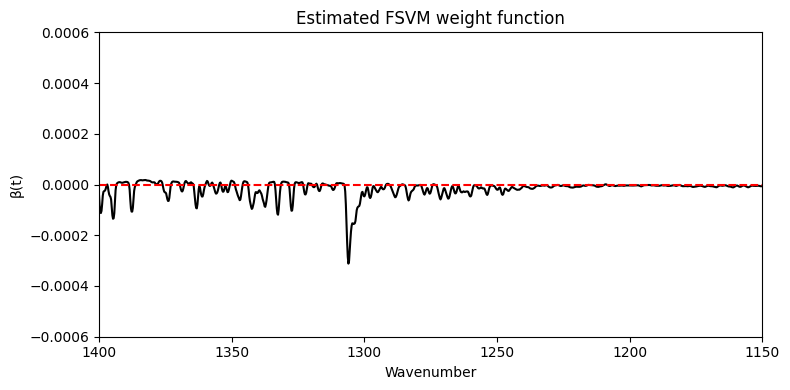

In [30]:
# Train linear SVM on full FPCA scores
clf_lin = SVC(kernel="linear", C=1.0)
clf_lin.fit(scores_K, y)

w = clf_lin.coef_.ravel()  # weights in FPCA space
phi_K = pca.components_[:K]

beta_t = np.dot(w, phi_K)

plt.figure(figsize=(8, 4))
plt.plot(wavenumbers, beta_t, color="black")
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Wavenumber")
plt.ylabel("β(t)")
plt.xlim(1400, 1150)
plt.ylim(-0.0006, 0.0006)
plt.title("Estimated FSVM weight function")
plt.tight_layout()
plt.show()


In [43]:
proj = scores_K @ w

mean_proj_H = proj[y == 0].mean()
mean_proj_PC = proj[y == 1].mean()

recon_H = mean_proj_H * beta_t
recon_PC = mean_proj_PC * beta_t

plt.figure(figsize=(10, 5))
plt.plot(wavenumbers, recon_H, label="Healthy direction", color="tab:blue")
plt.plot(wavenumbers, recon_PC, label="PC direction", color="tab:red")
plt.axhline(0, color="black", linestyle="--")
plt.xlabel("Wavenumber")
plt.ylabel("Weighted intensity")

plt.xlim(1150, 1400)
# plt.xlim(2700, 3400)
# plt.xlim(2150, 2200)
# plt.xlim(1150, 1400)
# plt.ylim(-0.0006, 0.0004)


# plt.ylim(-0.001, 0.001)
plt.title("Functional separation along FSVM decision axis")
plt.legend()
plt.tight_layout()
plt.show()


IndexError: boolean index did not match indexed array along axis 0; size of axis is 43 but size of corresponding boolean axis is 51

In [45]:
mean_proj_H

np.float64(-1.0275196252619734)

### Apply FSVM to chemically informed subdomains

In [32]:
import numpy as np
import pandas as pd

def extract_SR_matrix(df, center, width=15, horizontal = False):
    """
    Extract functional data matrix X (n_samples x n_wavenumbers)
    for a given spectral range.
    """
    wn_min, wn_max = center - width, center + width

    # assume df['wavenumber'] and df['intensity_baseline_corrected']
    # are stored as arrays / lists
    X = []
    wavenumbers_ref = None

    for _, row in df.iterrows():
        wn = np.array(row["wavenumber"])
        intensity = np.array(row["intensity_baseline_corrected"])

        mask = (wn >= wn_min) & (wn <= wn_max)

        if wavenumbers_ref is None:
            wavenumbers_ref = wn[mask]

        X.append(intensity[mask])
    if horizontal:
            return np.array(X), wavenumbers_ref

    return np.vstack(X), wavenumbers_ref

def fpca_train(X_train, n_fpc=5):
    """
    Perform FPCA on training functional data.
    """
    mean_func = X_train.mean(axis=0)
    Xc = X_train - mean_func

    # covariance in function space
    C = np.cov(Xc, rowvar=False)

    eigvals, eigvecs = np.linalg.eigh(C)
    idx = np.argsort(eigvals)[::-1]

    eigvecs = eigvecs[:, idx[:n_fpc]]

    scores = Xc @ eigvecs
    return mean_func, eigvecs, scores

def fpca_project(X, mean_func, eigvecs):
    Xc = X - mean_func
    return Xc @ eigvecs

from sklearn.svm import SVC
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import confusion_matrix

def fsvm_loocv_SR(X, y, n_fpc=5, C=1.0):
    loo = LeaveOneOut()
    decisions, y_true = [], []

    for train, test in loo.split(X):
        X_train, X_test = X[train], X[test]
        y_train, y_test = y[train], y[test]

        mean_func, eigvecs, train_scores = fpca_train(X_train, n_fpc)
        test_scores = fpca_project(X_test, mean_func, eigvecs)

        svm = SVC(kernel="linear", C=C)
        svm.fit(train_scores, y_train)

        decisions.append(svm.decision_function(test_scores)[0])
        y_true.append(y_test[0])

    decisions = np.array(decisions)
    y_true = np.array(y_true)

    # orientation fix
    if decisions[y_true == 0].mean() > decisions[y_true == 1].mean():
        decisions *= -1

    y_pred = (decisions > 0).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    return {
        "y_true": y_true,
        "y_pred": y_pred,
        "accuracy": (tp + tn) / len(y_true),
        "sensitivity": tp / (tp + fn) if (tp + fn) else 0,
        "specificity": tn / (tn + fp) if (tn + fp) else 0,
        "balanced_accuracy": 0.5 * (
            tp / (tp + fn) if (tp + fn) else 0 +
            tn / (tn + fp) if (tn + fp) else 0
        ),
        "decisions": decisions
    }



In [33]:
# List of SR centers only
SR_centers = [1005, 1050, 1170, 1190, 1203, 2170]

# Binary labels (PC vs H assumed already filtered upstream if needed)
y = (df["class"] == "PC").astype(int).values

results_per_sr = {}

print("Running FSVM per spectral region")
print("-----------------------------------------------------")

for c in SR_centers:
    print(f"SR center: {c} cm^-1")

    # Extract SR-specific matrix (function unchanged)
    X_sr, _ = extract_SR_matrix(df, c)

    # Run FSVM with LOOCV (function unchanged)
    metrics = fsvm_loocv_SR(X_sr, y, n_fpc=5)

    # Store results keyed by SR center
    results_per_sr[c] = metrics


Running FSVM per spectral region
-----------------------------------------------------
SR center: 1005 cm^-1
SR center: 1050 cm^-1
SR center: 1170 cm^-1
SR center: 1190 cm^-1
SR center: 1203 cm^-1
SR center: 2170 cm^-1


In [34]:
results_per_sr

{1005: {'y_true': array([0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1,
         0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0]),
  'y_pred': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0]),
  'accuracy': np.float64(0.6666666666666666),
  'sensitivity': np.float64(0.0),
  'specificity': np.float64(1.0),
  'balanced_accuracy': np.float64(0.0),
  'decisions': array([-0.99999414, -0.99998946, -0.99998749, -0.99999598, -0.99999345,
         -0.99998572, -0.99998632, -0.9999906 , -0.99998209, -0.99998716,
         -0.9999893 , -0.99998914, -0.99999094, -0.99999359, -0.9999893 ,
         -0.99998898, -0.99998928, -0.99998838, -0.99998953, -0.99999108,
         -0.99999218, -0.99999005, -0.99998731, -0.9999855 , -0.9999824 ,
         -0.99998905, -0.99998987, -0.99999132, -0.99998906, -1.000008  ,

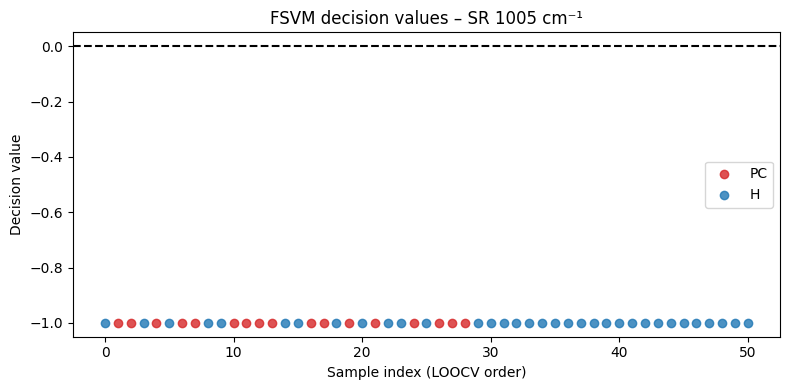

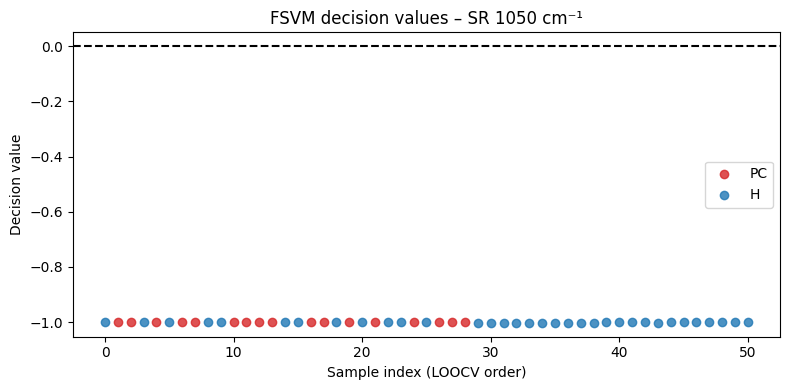

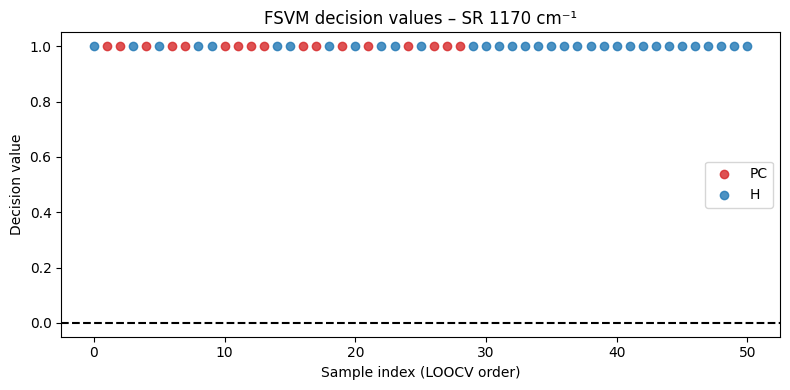

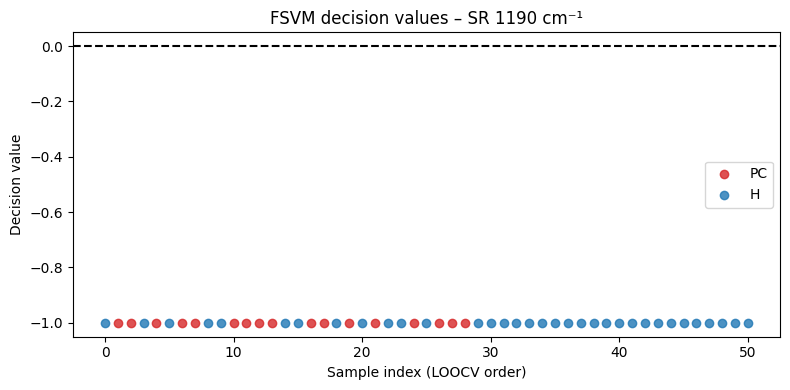

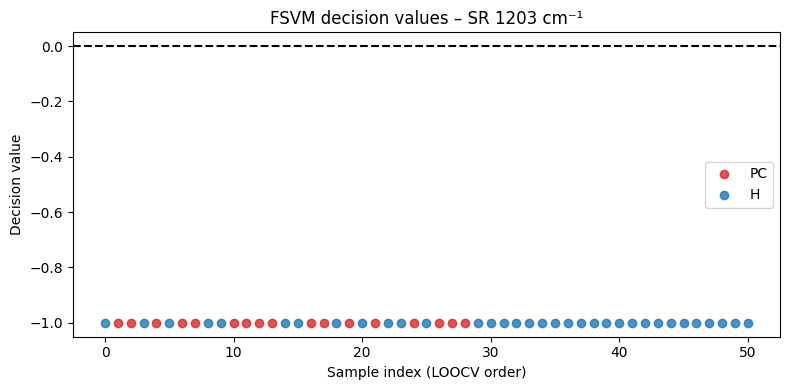

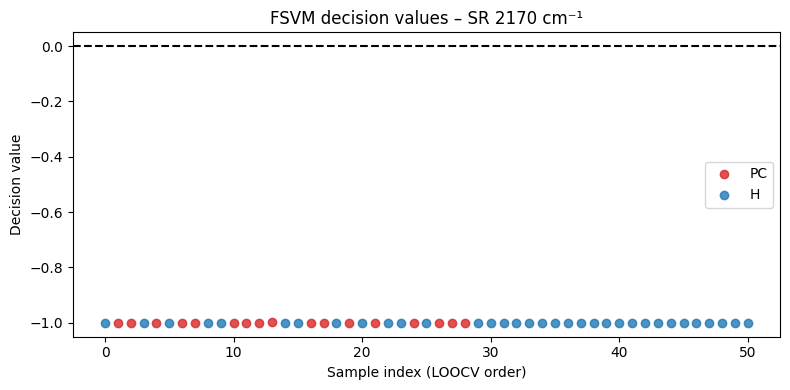

In [35]:
for sr_center, metrics in results_per_sr.items():

    plot_decision_values(
        decisions=metrics["decisions"],
        y_true=metrics["y_true"],
        title=f"FSVM decision values – SR {sr_center} cm⁻¹"
    )


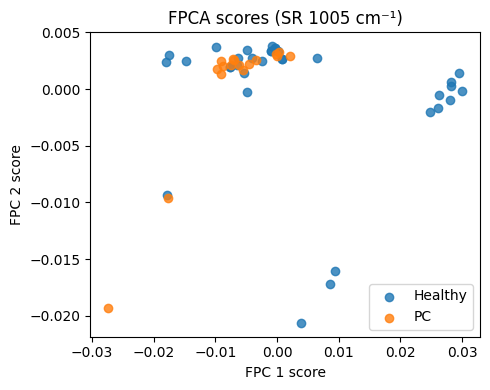

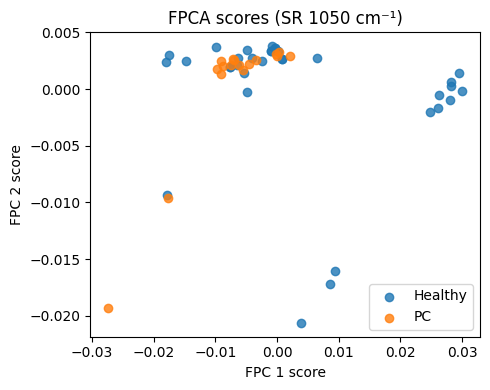

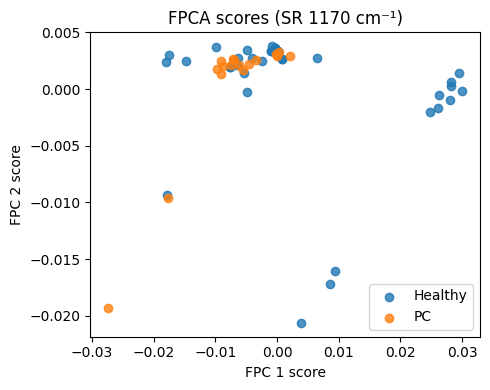

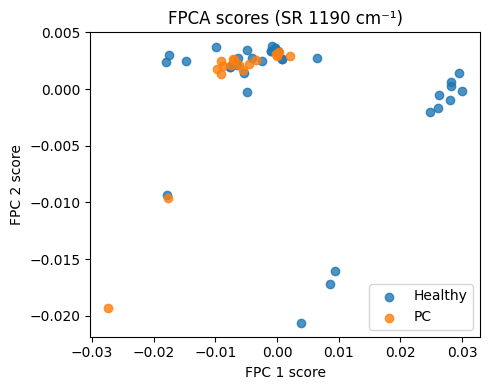

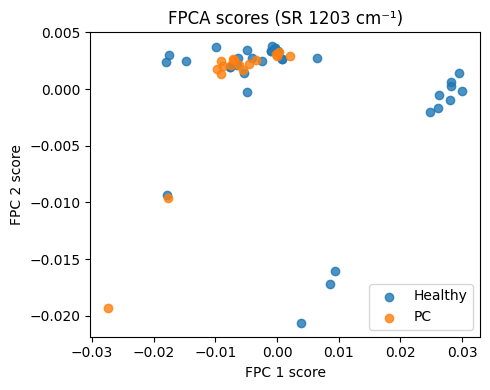

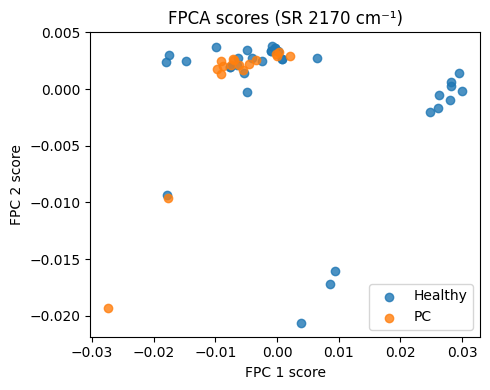

In [36]:
import matplotlib.pyplot as plt

def plot_fpca_scores_2d(X, y, sr_center, n_fpc=2):
    mean_func, eigvecs, scores = fpca_train(X, n_fpc=n_fpc)

    plt.figure(figsize=(5, 4))
    for cls, label, color in [(0, "Healthy", "tab:blue"),
                              (1, "PC", "tab:red")]:
        idx = y == cls
        plt.scatter(
            scores[idx, 0],
            scores[idx, 1],
            label=label,
            alpha=0.8
        )

    plt.xlabel("FPC 1 score")
    plt.ylabel("FPC 2 score")
    plt.title(f"FPCA scores (SR {sr_center} cm⁻¹)")
    plt.legend()
    plt.tight_layout()
    plt.show()
for sr in [1005, 1050, 1170, 1190, 1203, 2170]:
 
    plot_fpca_scores_2d(X_sr, y, sr_center=sr)



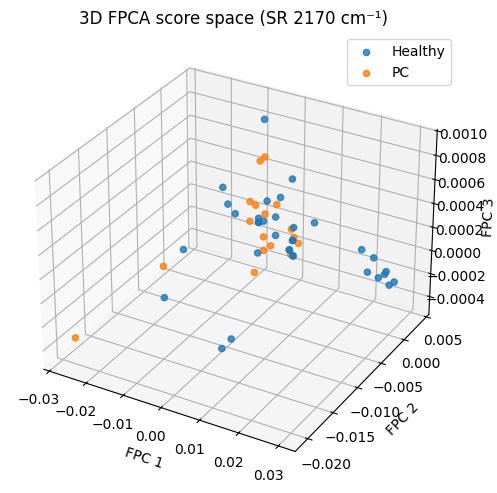

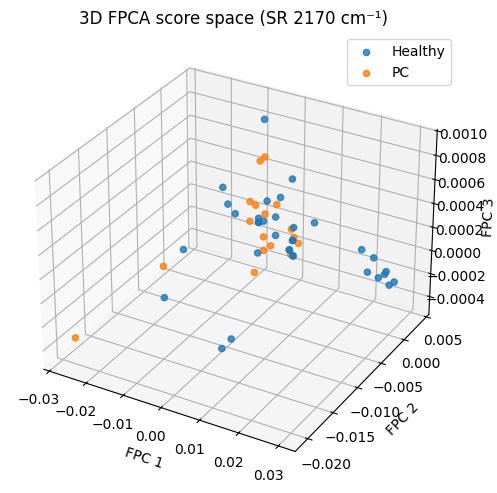

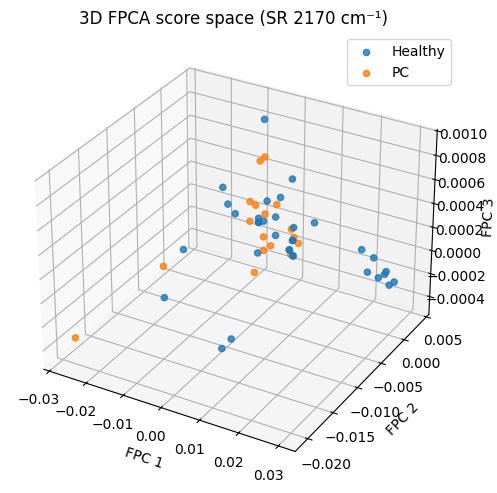

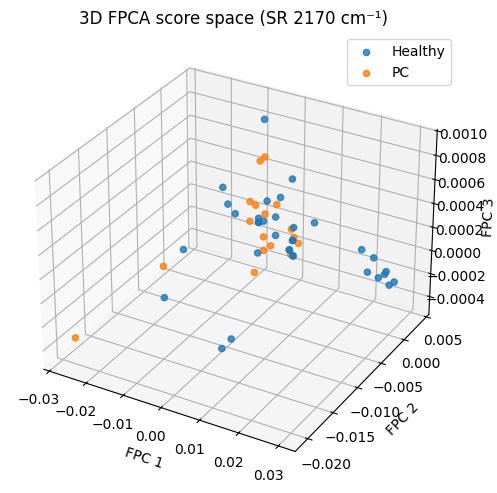

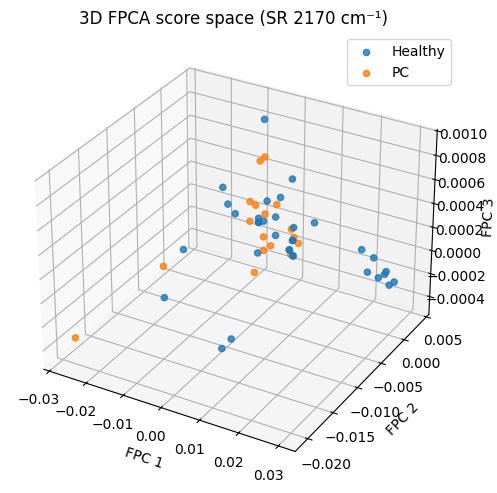

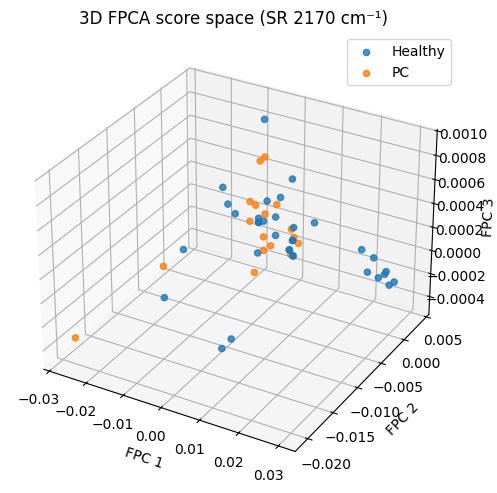

In [37]:
from mpl_toolkits.mplot3d import Axes3D

def plot_fpca_scores_3d(X, y, sr_center, n_fpc=5):
    mean_func, eigvecs, scores = fpca_train(X, n_fpc=n_fpc)

    fig = plt.figure(figsize=(6, 5))
    ax = fig.add_subplot(111, projection="3d")

    for cls, label, color in [(0, "Healthy", "tab:blue"),
                              (1, "PC", "tab:red")]:
        idx = y == cls
        ax.scatter(
            scores[idx, 0],
            scores[idx, 1],
            scores[idx, 2],
            label=label,
            alpha=0.8
        )

    ax.set_xlabel("FPC 1")
    ax.set_ylabel("FPC 2")
    ax.set_zlabel("FPC 3")
    ax.set_title(f"3D FPCA score space (SR {sr_center} cm⁻¹)")
    ax.legend()
    plt.tight_layout()
    plt.show()

for sr in [1005, 1050, 1170, 1190, 1203, 2170]:
    plot_fpca_scores_3d(X_sr, y, sr_center, n_fpc=3)


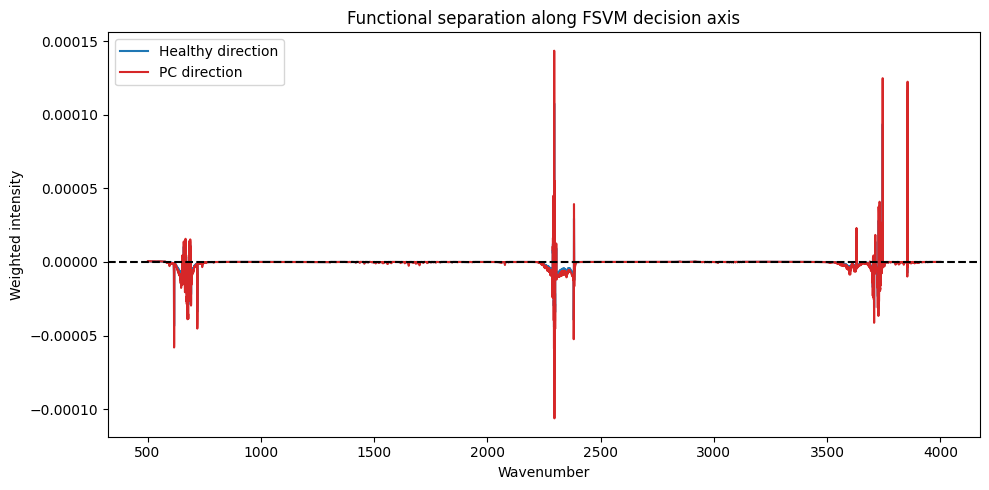

In [38]:
def plot_functional_separation(
    X, y, sr_center, n_fpc=5
):
    mean_func, eigvecs, scores = fpca_train(X, n_fpc)

    svm = SVC(kernel="linear", C=1.0)
    svm.fit(scores, y)

    # FSVM functional weight
    w_fpc = svm.coef_.ravel()
    w_func = eigvecs @ w_fpc   # back to function space

    proj = X @ w_func



    # proj = scores_K @ w

    mean_proj_H = proj[y == 0].mean()
    mean_proj_PC = proj[y == 1].mean()

    recon_H = mean_proj_H * beta_t
    recon_PC = mean_proj_PC * beta_t

    plt.figure(figsize=(10, 5))
    plt.plot(wavenumbers, recon_H, label="Healthy direction", color="tab:blue")
    plt.plot(wavenumbers, recon_PC, label="PC direction", color="tab:red")
    plt.axhline(0, color="black", linestyle="--")
    plt.xlabel("Wavenumber")
    plt.ylabel("Weighted intensity")

    # plt.xlim(1150, 1400)
    # plt.xlim(2700, 3400)
    # plt.xlim(2150, 2200)
    # plt.xlim(1150, 1400)
    # plt.ylim(-0.0006, 0.0004)


    # plt.ylim(-0.001, 0.001)
    plt.title("Functional separation along FSVM decision axis")
    plt.legend()
    plt.tight_layout()
    plt.show()








    # plt.figure(figsize=(5, 4))
    # for cls, label, color in [(0, "Healthy", "tab:blue"),
    #                           (1, "PC", "tab:red")]:
    #     idx = y == cls
    #     plt.hist(
    #         proj[idx],
    #         bins=10,
    #         alpha=0.6,
    #         label=label,
    #         density=True
    #     )

    # plt.xlabel("Projection onto FSVM functional direction")
    # plt.ylabel("Density")
    # plt.title(f"Functional separation (SR {sr_center} cm⁻¹)")
    # plt.legend()
    # plt.tight_layout()
    # plt.show()
plot_functional_separation(X_sr, y, sr_center=1005, n_fpc=5)



In [39]:
def extract_multi_SR_matrix(df, sr_centers, width=15):
    """
    Concatenates multiple SRs into a single functional domain
    """
    X_blocks = []
    wn_blocks = []

    for c in sr_centers:
        X_sr, wn_sr = extract_SR_matrix(df, c, width, horizontal = True)
        X_blocks.append(X_sr)
        wn_blocks.append(wn_sr)

    # Concatenate along wavenumber axis
    X_full = np.hstack(X_blocks)
    wn_full = np.concatenate(wn_blocks)

    return X_full, wn_full

def fsvm_loocv_multiSR(X, y, n_fpc=5, C=1):
    loo = LeaveOneOut()

    decisions = []
    y_true = []

    for train, test in loo.split(X):
        X_train, X_test = X[train], X[test]
        y_train, y_test = y[train], y[test]

        # ---- FPCA (inside fold) ----
        mean_func = X_train.mean(axis=0)
        Xc = X_train - mean_func

        Cmat = np.cov(Xc, rowvar=False)
        eigvals, eigvecs = np.linalg.eigh(Cmat)

        idx = np.argsort(eigvals)[::-1]
        eigvecs = eigvecs[:, idx[:n_fpc]]

        # FPC scores
        scores_train = Xc @ eigvecs
        scores_test = (X_test - mean_func) @ eigvecs

        # ---- Linear SVM ----
        svm = SVC(kernel="rbf", C=C, class_weight="balanced")
        svm.fit(scores_train, y_train)

        decision = svm.decision_function(scores_test)[0]
        decisions.append(decision)
        y_true.append(y_test[0])

    decisions = np.array(decisions)
    y_true = np.array(y_true)

    # orientation fix
    if decisions[y_true == 0].mean() > decisions[y_true == 1].mean():
        decisions = -decisions

    y_pred = (decisions > 0).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) else 0
    specificity = tn / (tn + fp) if (tn + fp) else 0

    return {
        "accuracy": (tp + tn) / len(y_true),
        "sensitivity": sensitivity,
        "specificity": specificity,
        "balanced_accuracy": 0.5 * (sensitivity + specificity),
        "decisions": decisions
    }

sr_centers = [1005, 1050, 1170, 1190, 1203, 2170]

X_full, wn_full = extract_multi_SR_matrix(df_bin, sr_centers)

results = fsvm_loocv_multiSR(X_full, y, n_fpc=2, C=1)

print(results)


{'accuracy': np.float64(0.4418604651162791), 'sensitivity': np.float64(0.7647058823529411), 'specificity': np.float64(0.23076923076923078), 'balanced_accuracy': np.float64(0.497737556561086), 'decisions': array([ 0.93785763,  1.00525624,  0.84665241,  0.99996519,  0.96490599,
        0.73616036,  0.8688401 ,  0.89825528,  0.72131464,  0.93244284,
        0.50022757,  0.92077597,  0.81243444,  0.79955493,  0.71242278,
        0.93657894,  0.80446636,  0.85118721,  0.59639042,  0.8529201 ,
        0.56829306, -0.18449293, -0.78135829, -0.66020798, -0.53612821,
       -0.65861592,  0.10055187, -0.29269334, -0.38125396, -0.71093738,
       -0.64546767,  0.83120534,  0.83843139,  0.83874022,  0.86403996,
       -0.88633374,  0.93198477,  0.93785763,  0.99996519,  0.85640954,
        0.58203011,  0.80016779,  0.85449422])}


In [40]:
from sklearn.svm import SVC

def fit_linear_fsvm_multiSR(X, y, n_fpc=5, C=1.0):
    """
    Fit linear FSVM on full data (no CV) for functional interpretation
    """
    # ---- FPCA ----
    mean_func = X.mean(axis=0)
    Xc = X - mean_func

    Cmat = np.cov(Xc, rowvar=False)
    eigvals, eigvecs = np.linalg.eigh(Cmat)
    idx = np.argsort(eigvals)[::-1][:n_fpc]
    eigvecs = eigvecs[:, idx]

    scores = Xc @ eigvecs

    # ---- Linear SVM ----
    svm = SVC(kernel="linear", C=C)
    svm.fit(scores, y)

    # FSVM functional weight
    w_fpc = svm.coef_.ravel()
    w_func = eigvecs @ w_fpc

    mean_H = X[y == 0].mean(axis=0)
    mean_PC = X[y == 1].mean(axis=0)

    return w_func, mean_H, mean_PC


import matplotlib.pyplot as plt

def plot_fsvm_curves_multiSR(
    X, y, wn_full, sr_centers, n_fpc=5
):
    w_func, mean_H, mean_PC = fit_linear_fsvm_multiSR(
        X, y, n_fpc=n_fpc
    )

    f_H = mean_H * w_func
    f_PC = mean_PC * w_func

    plt.figure(figsize=(9, 4))
    plt.plot(wn_full, f_H, label="Healthy", linewidth=2)
    plt.plot(wn_full, f_PC, label="PC", linewidth=2)

    plt.axhline(0, color="black", linestyle="--", linewidth=1)

    # Mark SR boundaries
    for c in sr_centers:
        plt.axvline(c, color="gray", linestyle=":", alpha=0.4)

    plt.xlabel("Wavenumber (cm⁻¹)")
    plt.ylabel("FSVM-weighted intensity")
    plt.title("FSVM functional separation – concatenated SRs")
    plt.legend()
    plt.tight_layout()
    plt.show()

# plot_fsvm_curves_multiSR(
#     X=X_full,
#     y=y,
#     wn_full=wn_full,
#     sr_centers=sr_centers,
#     n_fpc=2
# )

# plt.figure(figsize=(9, 4))
# plt.plot(
#     wn_full,
#     f_PC - f_H,
#     color="black",
#     linewidth=2
# )

# for c in sr_centers:
#     plt.axvline(c, color="gray", linestyle=":", alpha=0.4)

# plt.axhline(0, linestyle="--")
# plt.xlabel("Wavenumber (cm⁻¹)")
# plt.ylabel("PC − H (FSVM contribution)")
# plt.title("FSVM discriminative function – concatenated SRs")
# plt.tight_layout()
# plt.show()


In [41]:
plot_fsvm_curves_multiSR(
    X_full, y, wn_full, sr_centers, n_fpc=5
)

ValueError: Found input variables with inconsistent numbers of samples: [43, 51]